In [80]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict

def process_rw_file(filepath, plot=True):
    """
    Reads a random walk txt file.
    Each word is treated as a node.
    Consecutive words form directed edges.

    Returns:
        adj_df         : raw adjacency matrix
        word_counts    : total occurrences per node
        adj_row_prob   : row-normalized transition matrix
    """
    
    from collections import defaultdict
    import numpy as np
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt
    import os

    edge_counts = defaultdict(int)
    nodes = set()

    # Read file
    with open(filepath, "r") as f:
        for line in f:
            words = line.strip().split()
            
            for i in range(len(words) - 1):
                src = words[i]
                dst = words[i+1]
                edge_counts[(src, dst)] += 1
                nodes.add(src)
                nodes.add(dst)

    nodes = sorted(nodes)
    node_index = {node: i for i, node in enumerate(nodes)}

    # Build adjacency matrix
    adj_matrix = np.zeros((len(nodes), len(nodes)))
    total_edges = sum(edge_counts.values())

    for (src, dst), count in edge_counts.items():
        i = node_index[src]
        j = node_index[dst]
        adj_matrix[i, j] = count

    adj_df = pd.DataFrame(adj_matrix, index=nodes, columns=nodes)

    # Node occurrences
    word_counts = adj_df.sum(axis=0) + adj_df.sum(axis=1)

    # Symmetrixed adjacency for undirected counts (optional, not used in heatmaps)
    adj_symm = (adj_df+adj_df.T)

    # Row-normalized symmetrized adjacency (optional, not used in heatmaps)
    # adj_symm_row_prob = adj_symm.div(adj_symm.sum(axis=1), axis=0).fillna(0)
    adj_symm_row_prob = adj_symm

    # Global percentage matrix
    adj_percent = (adj_df / total_edges) * 100

    # Row-normalized transition probabilities
    adj_row_prob = adj_df.div(adj_df.sum(axis=1), axis=0).fillna(0)

    if plot:

        # ---------- Heatmap 1: Global % of edges ----------
        plt.figure(figsize=(10, 8))
        sns.heatmap(
            adj_percent,
            cmap="viridis",
            annot=True,
            fmt=".1f",
            cbar_kws={"label": "% of total edges"}
        )

        x_labels = [f"{node}\n({int(word_counts[node])})" for node in nodes]
        y_labels = [f"{node}\n({int(word_counts[node])})" for node in nodes]

        plt.xticks(np.arange(len(nodes)) + 0.5, x_labels, rotation=45, ha="right")
        plt.yticks(np.arange(len(nodes)) + 0.5, y_labels, rotation=0)

        plt.title(f"Global Edge Distribution (%)\n{os.path.basename(filepath)}")
        plt.xlabel("Destination")
        plt.ylabel("Source")
        plt.tight_layout()
        plt.show()

        # ---------- Heatmap 2: Symmetrized row-normalized transition probs ----------
        plt.figure(figsize=(10, 8))
        sns.heatmap(
            adj_symm_row_prob,
            cmap="viridis",
            annot=True,
            fmt=".2f",
            cbar_kws={"label": "P(destination | source) (symmetrized)"}
        )
        plt.xticks(np.arange(len(nodes)) + 0.5, nodes, rotation=45, ha="right")
        plt.yticks(np.arange(len(nodes)) + 0.5, nodes, rotation=0)
        plt.title(f"Symmetrized Transition Count\n{os.path.basename(filepath)}")
        plt.xlabel("Destination")
        plt.ylabel("Source")
        plt.tight_layout()
        plt.show()


        # ---------- Heatmap 3: Row-normalized transition probs ----------
        plt.figure(figsize=(10, 8))
        sns.heatmap(
            adj_row_prob,
            cmap="viridis",
            annot=True,
            fmt=".2f",
            cbar_kws={"label": "P(destination | source)"}
        )

        plt.xticks(np.arange(len(nodes)) + 0.5, nodes, rotation=45, ha="right")
        plt.yticks(np.arange(len(nodes)) + 0.5, nodes, rotation=0)

        plt.title(f"Row-Normalized Transition Probabilities\n{os.path.basename(filepath)}")
        plt.xlabel("Destination")
        plt.ylabel("Source")
        plt.tight_layout()
        plt.show()

    return adj_df, word_counts, adj_row_prob



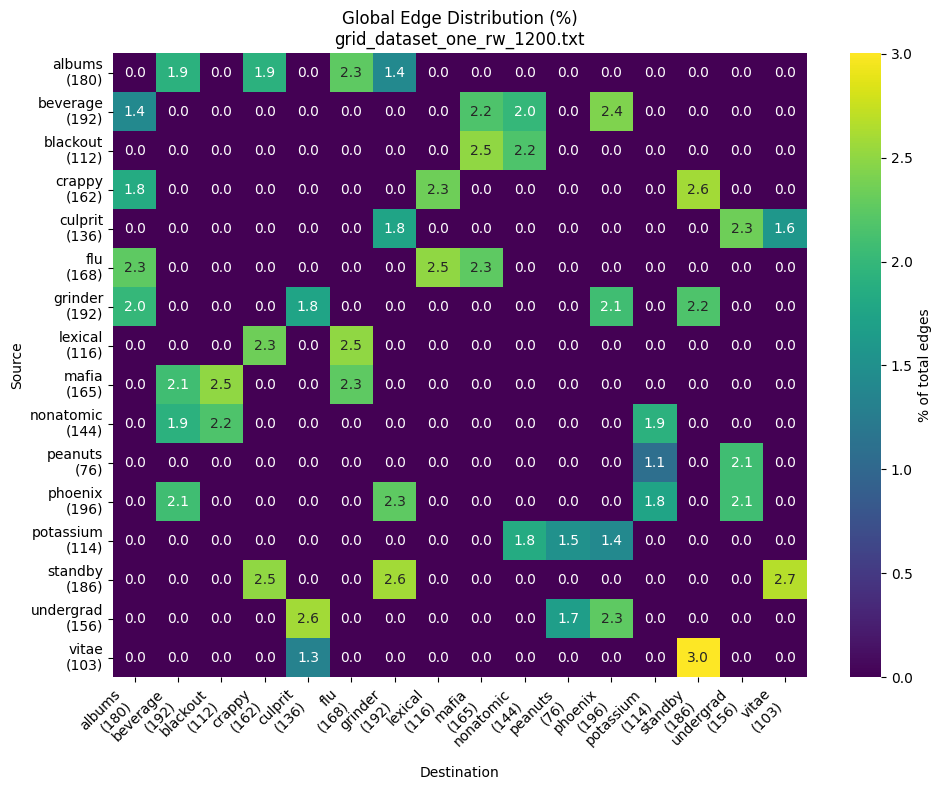

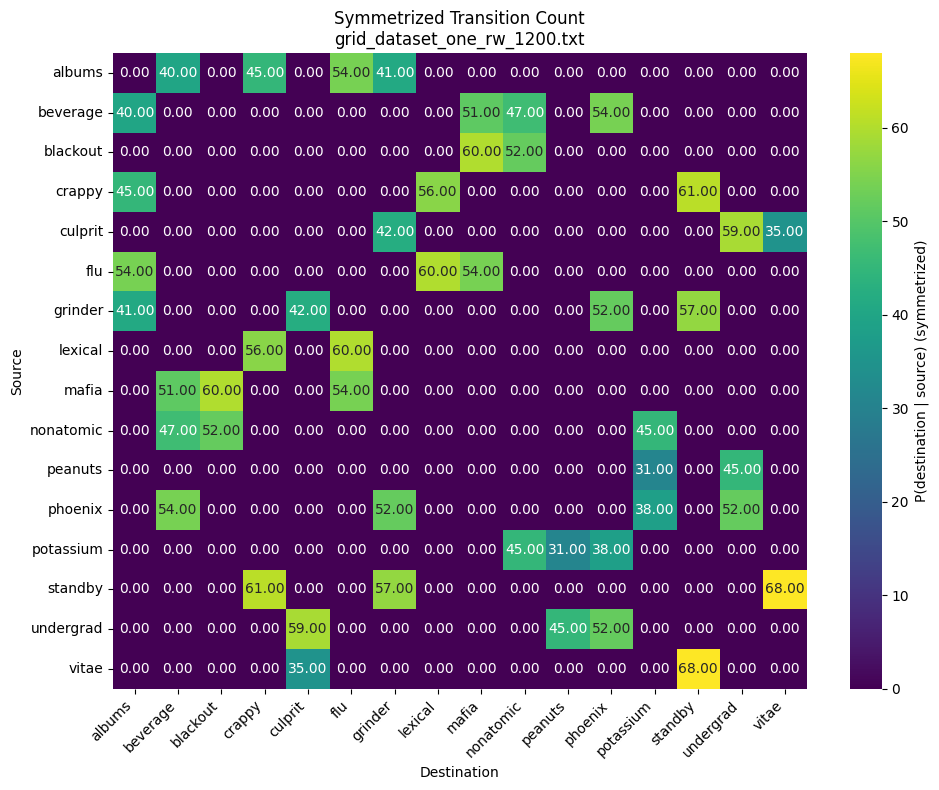

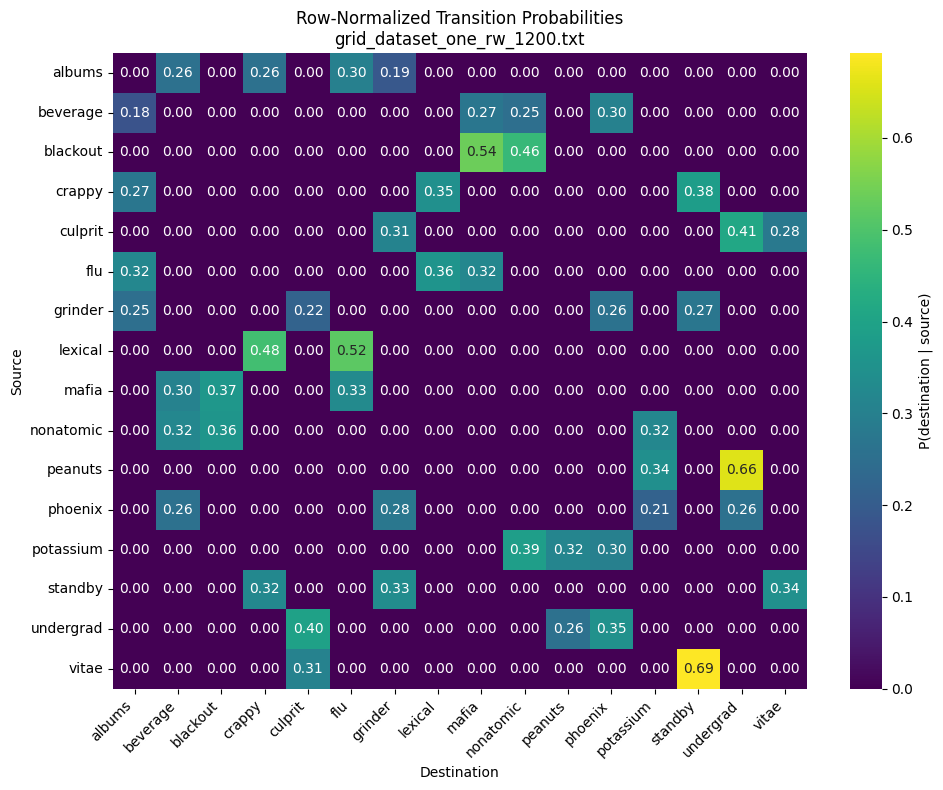

In [88]:
filepath = "../data/one_random_walk/grid_16/grid_dataset_one_rw_1200.txt"
adj = process_rw_file(filepath)
